# Indian house price prediction

Can we guess the asking price of a listing from size, city, BHK, and a
few flags?

The file is the training split of the
[House Price Prediction Challenge](https://www.kaggle.com/datasets/anmolkumar/house-price-prediction-challenge)
on Kaggle (MachineHack). 29,451 listings. The Kaggle test file has no
prices, so I hold out 20% of train instead.

**Target:** `target(price_in_lacs)` — asking price in ₹ lakh.

I am going to:

1. Clean duplicates and a handful of impossible rows
2. Pull a city out of `address`
3. Look at price by city / BHK / who posted it
4. Train a model **without** ₹/sqft (that number *is* the price)
5. Score rupee error on the holdout

Run this notebook from the repo root so `data/train.csv` resolves.


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["savefig.bbox"] = "tight"

BLUE = "#4C78A8"
ORANGE = "#F58518"


def repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, cwd.parent]:
        if (candidate / "data" / "train.csv").exists():
            return candidate
    return cwd


ROOT = repo_root()
DATA_PATH = ROOT / "data" / "train.csv"
FIG_DIR = ROOT / "reports" / "figures"
MODEL_DIR = ROOT / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"missing {DATA_PATH}"
print("loaded", DATA_PATH.name)
print("figures ->", FIG_DIR.relative_to(ROOT))


loaded train.csv
figures -> reports/figures


## 1. Load


In [2]:
raw = pd.read_csv(DATA_PATH)
print("rows, columns:", raw.shape)
raw.head()


rows, columns: (29451, 12)


,posted_by,under_construction,rera,bhk_no,bhk_or_rk,square_ft,ready_to_move,resale,address,longitude,latitude,target(price_in_lacs)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [3]:
raw.info()
print()
print("missing values:", int(raw.isna().sum().sum()))
print("exact duplicate rows:", int(raw.duplicated().sum()))
print()
print(raw["posted_by"].value_counts())
print()
print("under_construction vs ready_to_move:")
print(pd.crosstab(raw["under_construction"], raw["ready_to_move"]))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   posted_by              29451 non-null  object 
 1   under_construction     29451 non-null  int64  
 2   rera                   29451 non-null  int64  
 3   bhk_no                 29451 non-null  int64  
 4   bhk_or_rk              29451 non-null  object 
 5   square_ft              29451 non-null  float64
 6   ready_to_move          29451 non-null  int64  
 7   resale                 29451 non-null  int64  
 8   address                29451 non-null  object 
 9   longitude              29451 non-null  float64
 10  latitude               29451 non-null  float64
 11  target(price_in_lacs)  29451 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 2.7+ MB

missing values: 0
exact duplicate rows: 401

posted_by
Dealer     18291
Owner      10538
Builder    

No missing values. 401 duplicate rows. `ready_to_move` is the exact
opposite of `under_construction` — every row. I will keep
`under_construction` only.

`BHK_OR_RK` is BHK on 29,427 / 29,451 rows. Not useful.


In [4]:
print(raw["target(price_in_lacs)"].describe(percentiles=[0.5, 0.95, 0.99]))
print()
print(raw["square_ft"].describe(percentiles=[0.5, 0.95, 0.99]))
print()
print("price max ₹ lakh:", raw["target(price_in_lacs)"].max())
print("sqft max:", raw["square_ft"].max())
print()
print("longitude col range:", raw["longitude"].min(), "→", raw["longitude"].max())
print("latitude col range:", raw["latitude"].min(), "→", raw["latitude"].max())
print(
    "share of longitude-col inside India latitudes 8–37:",
    ((raw["longitude"] >= 8) & (raw["longitude"] <= 37)).mean().round(3),
)


count    29451.000000
mean       142.898746
std        656.880713
min          0.250000
50%         62.000000
95%        300.000000
99%       1045.000000
max      30000.000000
Name: target(price_in_lacs), dtype: float64

count    2.945100e+04
mean     1.980217e+04
std      1.901335e+06
min      3.000000e+00
50%      1.175057e+03
95%      2.619048e+03
99%      5.462569e+03
max      2.545455e+08
Name: square_ft, dtype: float64

price max ₹ lakh: 30000.0
sqft max: 254545454.5

longitude col range: -37.7130075 → 59.912884
latitude col range: -121.7612481 → 152.962676
share of longitude-col inside India latitudes 8–37: 0.995


The price column has a ₹300 crore listing and a 254 million sq ft
listing. Those are not 2–3 BHK flats.

The columns named `longitude` and `latitude` look swapped. Bangalore
shows up as 12.97 / 77.60, which is right for India only if the first
number is latitude. I am not using the coordinates as features.


## 2. Cleaning

- Drop exact duplicates
- City = last token of `address` after a comma
- Keep 200–8,000 sq ft, ₹5–1,500 lakh, BHK ≤ 8
- Rename the target to `price_lakh`


In [5]:
n_raw = len(raw)
n_dup = int(raw.duplicated().sum())
df = raw.drop_duplicates().reset_index(drop=True)

df["city"] = df["address"].str.split(",").str[-1].str.strip()
df = df.rename(columns={"target(price_in_lacs)": "price_lakh"})

keep = (
    (df["square_ft"] >= 200)
    & (df["square_ft"] <= 8_000)
    & (df["price_lakh"] >= 5)
    & (df["price_lakh"] <= 1_500)
    & (df["bhk_no"] <= 8)
)
n_junk = int((~keep).sum())
df = df.loc[keep].reset_index(drop=True)

print(f"raw rows:           {n_raw:,}")
print(f"duplicates dropped: {n_dup:,}")
print(f"junk rows dropped:  {n_junk:,}")
print(f"rows left:          {len(df):,}")
print(f"median price:       ₹{df['price_lakh'].median():.0f} lakh")
print(f"mean price:         ₹{df['price_lakh'].mean():.1f} lakh")
print(f"median sq ft:       {df['square_ft'].median():,.0f}")
print(f"unique cities:      {df['city'].nunique()}")


raw rows:           29,451
duplicates dropped: 401
junk rows dropped:  339
rows left:          28,711
median price:       ₹61 lakh
mean price:         ₹96.2 lakh
median sq ft:       1,169
unique cities:      253


## 3. Exploratory plots

₹/sqft below is **only** for charts. I drop it before fitting.


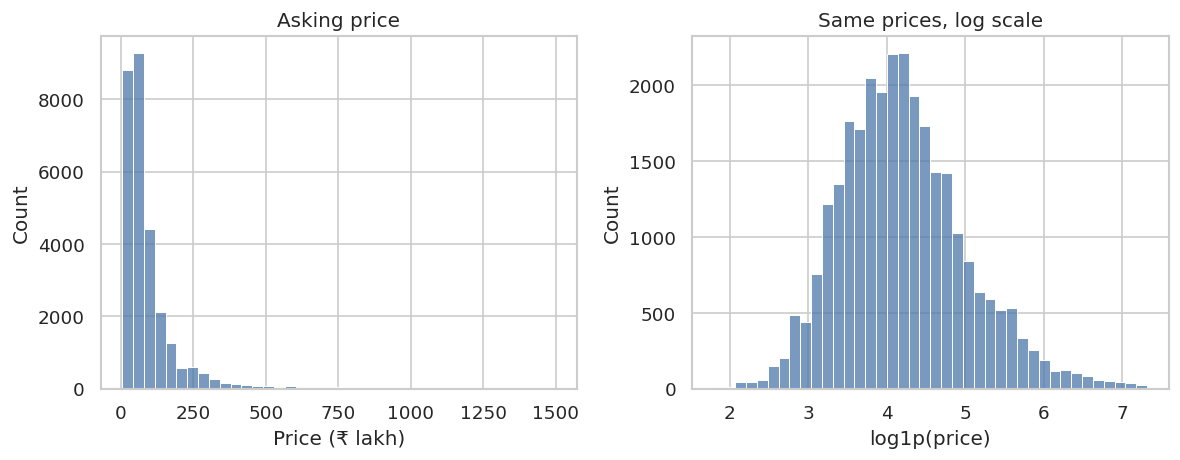

median ₹ lakh: 61.0   mean: 96.2


In [6]:
df["pps"] = df["price_lakh"] * 100_000 / df["square_ft"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df["price_lakh"], bins=40, ax=axes[0], color=BLUE)
axes[0].set_xlabel("Price (₹ lakh)")
axes[0].set_title("Asking price")
sns.histplot(np.log1p(df["price_lakh"]), bins=40, ax=axes[1], color=BLUE)
axes[1].set_xlabel("log1p(price)")
axes[1].set_title("Same prices, log scale")
fig.tight_layout()
fig.savefig(FIG_DIR / "price_distribution.png")
plt.show()
print("median ₹ lakh:", df["price_lakh"].median(), "  mean:", round(df["price_lakh"].mean(), 1))


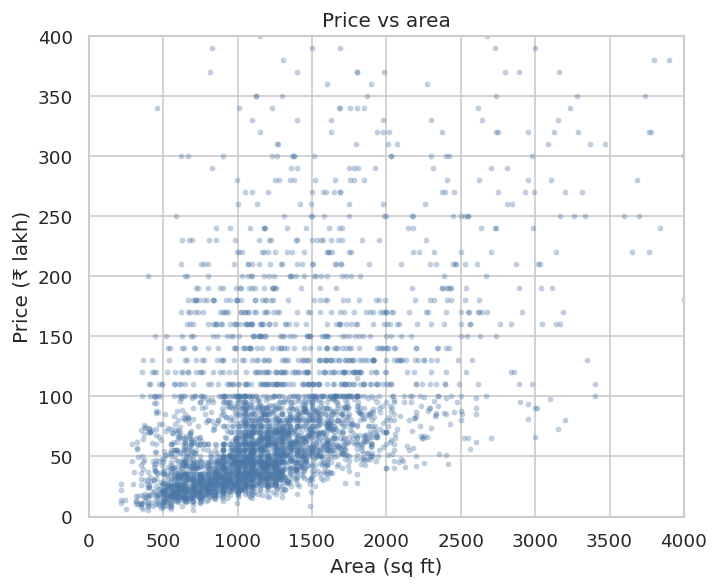

corr log(area), log(price): 0.587


In [7]:
sample = df.sample(min(4000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.scatter(sample["square_ft"], sample["price_lakh"], s=12, alpha=0.35, c=BLUE, linewidths=0)
ax.set_xlabel("Area (sq ft)")
ax.set_ylabel("Price (₹ lakh)")
ax.set_title("Price vs area")
ax.set_xlim(0, 4000)
ax.set_ylim(0, 400)
fig.savefig(FIG_DIR / "price_vs_area.png")
plt.show()
print(
    "corr log(area), log(price):",
    round(np.corrcoef(np.log1p(df["square_ft"]), np.log1p(df["price_lakh"]))[0, 1], 3),
)


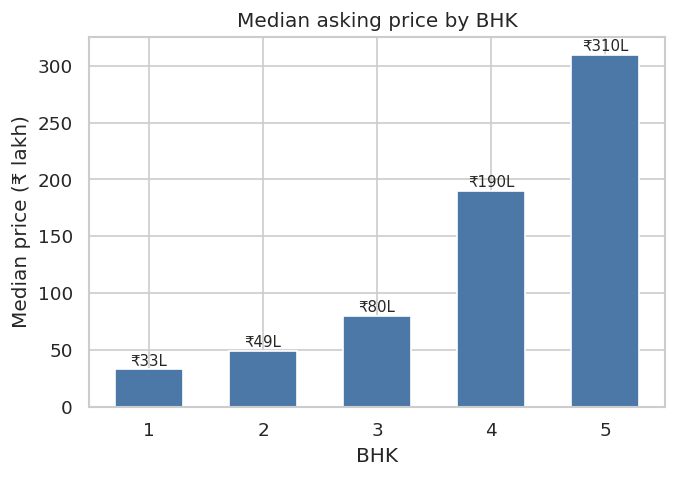

        count  median
bhk_no               
1        3494    33.0
2       13077    49.2
3       10263    80.0
4        1655   190.0
5         168   310.0


In [8]:
bhk = (
    df.loc[df["bhk_no"] <= 5]
    .groupby("bhk_no")["price_lakh"]
    .agg(["count", "median"])
)
fig, ax = plt.subplots(figsize=(6.2, 4.0))
ax.bar(bhk.index.astype(str), bhk["median"], color=BLUE, width=0.6)
ax.set_xlabel("BHK")
ax.set_ylabel("Median price (₹ lakh)")
ax.set_title("Median asking price by BHK")
for i, (n, v) in enumerate(zip(bhk["count"], bhk["median"])):
    ax.text(i, v + 3, f"₹{v:.0f}L", ha="center", fontsize=9)
fig.savefig(FIG_DIR / "median_price_by_bhk.png")
plt.show()
print(bhk)


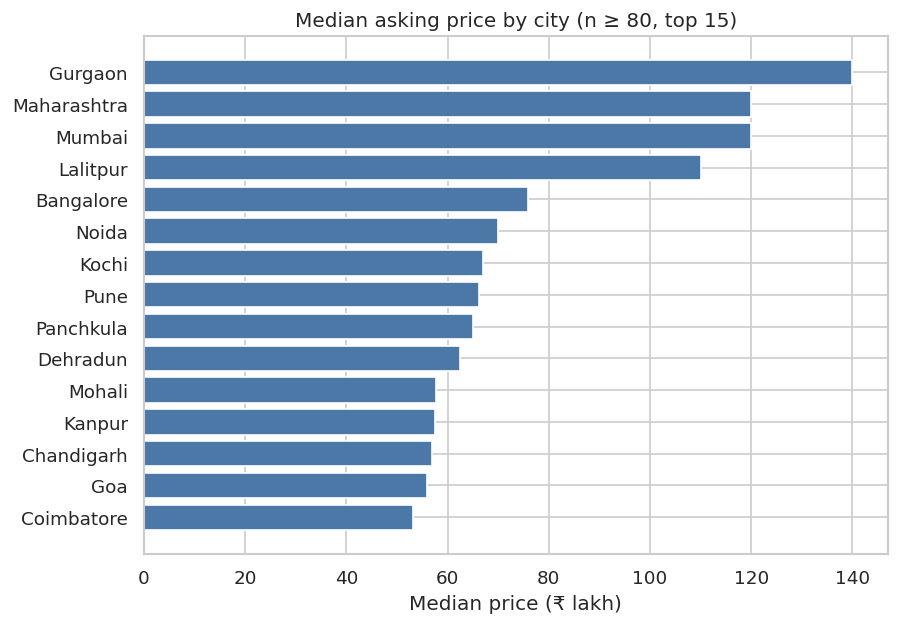

                n  median      pps
city                              
Gurgaon       408   140.0   6887.0
Maharashtra  1531   120.0  13428.0
Mumbai       1980   120.0  13379.0
Lalitpur     2900   110.0  12465.0
Bangalore    4235    76.0   5750.0
Noida        1706    70.0   5077.0
Kochi         202    67.0   4748.0
Pune         1966    66.2   6470.0
Panchkula      80    65.0   4049.5
Dehradun      128    62.5   4116.0
Mohali        530    57.8   3864.5
Kanpur         88    57.5   4406.5


In [9]:
city_stats = (
    df.groupby("city")
    .agg(n=("price_lakh", "count"), median=("price_lakh", "median"), pps=("pps", "median"))
    .query("n >= 80")
    .sort_values("median", ascending=False)
)
top = city_stats.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8.0, 5.6))
ax.barh(top.index, top["median"], color=BLUE)
ax.set_xlabel("Median price (₹ lakh)")
ax.set_title("Median asking price by city (n ≥ 80, top 15)")
fig.savefig(FIG_DIR / "median_price_by_city.png")
plt.show()
print(city_stats.head(12).round(1))


Gurgaon ₹140 lakh, Mumbai ₹120 lakh, Bangalore ₹76 lakh, Jaipur ₹36 lakh.
That ordering matches what I would expect, with one catch: **Lalitpur**
sits next to Mumbai.

I peeked at those addresses: `Mulund (West),Lalitpur`,
`Thane West,Lalitpur`, `Chembur,Lalitpur`. Same for city = Maharashtra.
₹/sqft there is ~₹12–13k, like Mumbai, not Uttar Pradesh. The city field
is just the last comma-separated token. I still use it — the model can
treat “Lalitpur” as a Mumbai-ish bucket — I just would not put it on a
map.


Lalitpur address tails:
address
Hiranandani Estate,Lalitpur    61
Mulund (West),Lalitpur         61
Chembur (East),Lalitpur        60
Ghodbunder Road,Lalitpur       59
Kharghar,Lalitpur              58
Kolshet Road,Lalitpur          53
Chembur,Lalitpur               52
Malad (West),Lalitpur          52
Name: count, dtype: int64



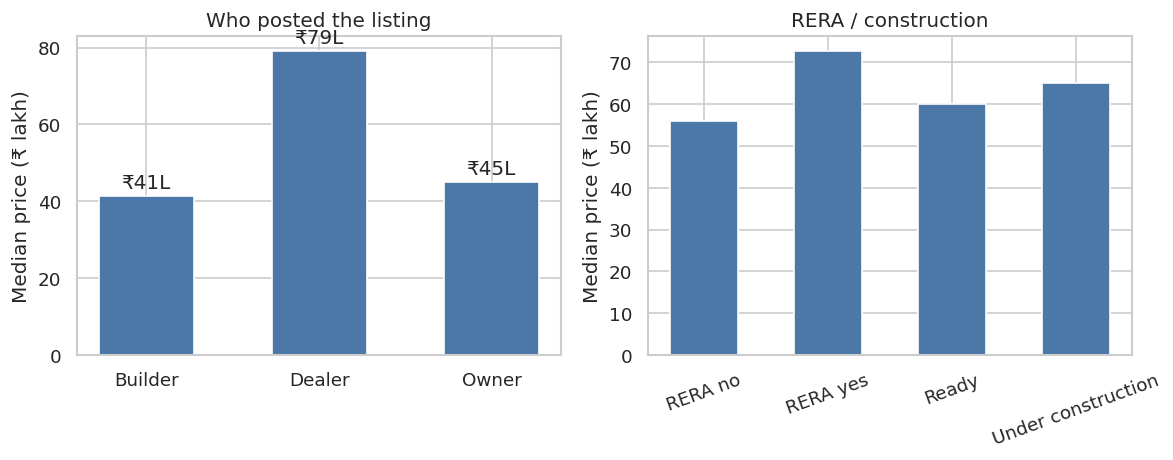

           count  median
posted_by               
Builder      602   41.45
Dealer     17740   79.00
Owner      10369   45.00


In [10]:
print("Lalitpur address tails:")
print(df.loc[df["city"] == "Lalitpur", "address"].value_counts().head(8))
print()
who = df.groupby("posted_by")["price_lakh"].agg(["count", "median"])
fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))
axes[0].bar(who.index, who["median"], color=BLUE, width=0.55)
axes[0].set_ylabel("Median price (₹ lakh)")
axes[0].set_title("Who posted the listing")
for i, v in enumerate(who["median"]):
    axes[0].text(i, v + 2, f"₹{v:.0f}L", ha="center")

flags = pd.DataFrame(
    {
        "RERA no": df.loc[df["rera"] == 0, "price_lakh"].median(),
        "RERA yes": df.loc[df["rera"] == 1, "price_lakh"].median(),
        "Ready": df.loc[df["under_construction"] == 0, "price_lakh"].median(),
        "Under construction": df.loc[df["under_construction"] == 1, "price_lakh"].median(),
    },
    index=["median"],
).T
axes[1].bar(flags.index, flags["median"], color=BLUE, width=0.55)
axes[1].set_ylabel("Median price (₹ lakh)")
axes[1].set_title("RERA / construction")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIG_DIR / "price_by_flags.png")
plt.show()
print(who)


## 4. Features

Known at listing time: area, BHK, city, who posted it, RERA, resale,
under construction.

Cities with fewer than 80 listings go to `Other`. BHK is capped at 6.
`is_metro` is a small hand list (Mumbai, Bangalore, the NCR names, …)
plus the `Maharashtra` bucket, which is mostly MMR.

**Not used:** `pps` / ₹/sqft, `ready_to_move`, `bhk_or_rk`, raw lat/lon,
the original address string.


In [11]:
METROS = {
    "Mumbai", "Bangalore", "Delhi", "Chennai", "Kolkata", "Hyderabad", "Pune",
    "Ahmedabad", "Gurgaon", "Noida", "Ghaziabad", "Faridabad", "Maharashtra",
}

vc = df["city"].value_counts()
KEEP_CITIES = set(vc[vc >= 80].index)

df["city_group"] = df["city"].where(df["city"].isin(KEEP_CITIES), "Other")
df["is_metro"] = df["city"].isin(METROS).astype(int)
df["log_sqft"] = np.log1p(df["square_ft"])
df["bhk"] = df["bhk_no"].clip(upper=6)

NUMERIC = ["log_sqft", "bhk", "rera", "under_construction", "resale", "is_metro"]
CATEGORICAL = ["posted_by", "city_group"]
FEATURES = NUMERIC + CATEGORICAL

print("city groups:", df["city_group"].nunique(), "  Other:", int((df["city_group"] == "Other").sum()))
print("features:", FEATURES)


city groups: 42   Other: 2643
features: ['log_sqft', 'bhk', 'rera', 'under_construction', 'resale', 'is_metro', 'posted_by', 'city_group']


## 5. Train / test split

Random 80/20. I model `log1p(price)` because the rupee histogram is a
long right tail, then convert predictions back to lakh before scoring.


In [12]:
X = df[FEATURES]
y = np.log1p(df["price_lakh"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
y_test_lakh = np.expm1(y_test)

print(f"train: {len(X_train):,}   test: {len(X_test):,}")
print(f"test median price: ₹{y_test_lakh.median():.1f} lakh")


train: 22,968   test: 5,743
test median price: ₹61.8 lakh


## 6. Models

1. **Median price** — dummy
2. **Ridge** — scaled numbers + one-hot cities
3. **Random forest**
4. **Gradient boosting** — main model

No ₹/sqft. No PyCaret. Thresholds are just sklearn defaults plus a
depth cap so a 22k-row forest does not memorize every listing.


In [13]:
def evaluate(name, pred_log):
    pred = np.expm1(pred_log)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_test_lakh, pred),
        "MedAE": float(np.median(np.abs(y_test_lakh - pred))),
        "RMSE": mean_squared_error(y_test_lakh, pred) ** 0.5,
        "R2": r2_score(y_test_lakh, pred),
        "MAPE": float(np.mean(np.abs((y_test_lakh - pred) / y_test_lakh)) * 100),
        "R2_log": r2_score(y_test, pred_log),
    }


dummy = DummyRegressor(strategy="median")
dummy.fit(X_train, y_train)
dummy_scores = evaluate("Median price", dummy.predict(X_test))

ridge = Pipeline(
    [
        (
            "prep",
            ColumnTransformer(
                [
                    ("num", StandardScaler(), NUMERIC),
                    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
                ]
            ),
        ),
        ("model", Ridge(alpha=1.0)),
    ]
)
ridge.fit(X_train, y_train)
ridge_pred_log = ridge.predict(X_test)
ridge_scores = evaluate("Ridge", ridge_pred_log)

tree_prep = ColumnTransformer(
    [
        ("num", "passthrough", NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
    ]
)

forest = Pipeline(
    [
        ("prep", tree_prep),
        (
            "model",
            RandomForestRegressor(
                n_estimators=250,
                max_depth=16,
                min_samples_leaf=4,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)
forest.fit(X_train, y_train)
forest_pred_log = forest.predict(X_test)
forest_scores = evaluate("Random forest", forest_pred_log)

boost = Pipeline(
    [
        ("prep", tree_prep),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.08,
                subsample=0.8,
                random_state=42,
            ),
        ),
    ]
)
boost.fit(X_train, y_train)
boost_pred_log = boost.predict(X_test)
boost_pred = np.expm1(boost_pred_log)
boost_scores = evaluate("Gradient boosting", boost_pred_log)

results = pd.DataFrame([dummy_scores, ridge_scores, forest_scores, boost_scores]).set_index("model")
results[["MAE", "MedAE", "RMSE", "R2", "MAPE"]].round(2)


,MAE,MedAE,RMSE,R2,MAPE
model,,,,,
Median price,57.60,28.60,124.23,-0.08,67.66
Ridge,30.78,13.62,70.39,0.65,31.63
Random forest,29.32,11.66,68.13,0.67,29.67
Gradient boosting,28.53,12.07,64.41,0.71,28.71


Gradient boosting is the best rupee ranker (R² 0.71, MAE ₹28.5 lakh).
Median error is ₹12.1 lakh — that is the “typical listing” number I
would quote. Mean error is higher because a few Mumbai / Gurgaon homes
are way up the tail.

The dummy already tells you the floor: always guessing ₹61 lakh is off
by ₹29 lakh typically.


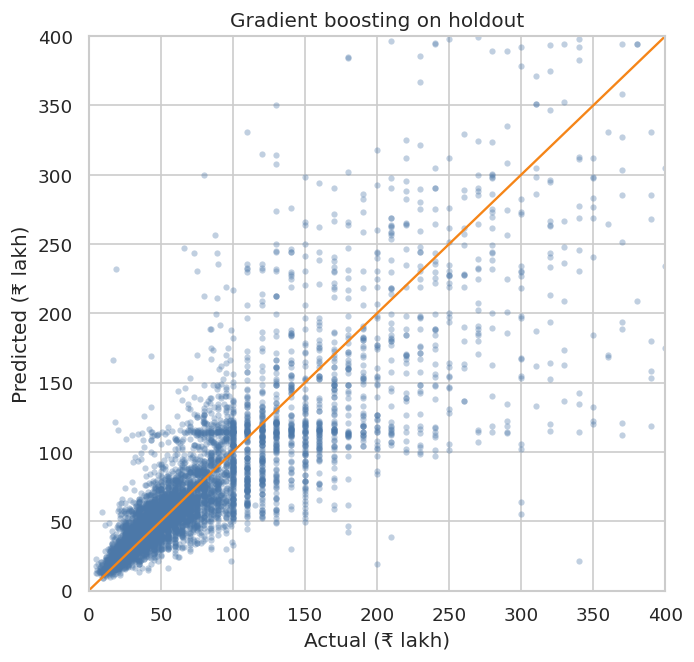

In [14]:
fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(y_test_lakh, boost_pred, s=14, alpha=0.35, c=BLUE, linewidths=0)
lim = min(400, float(max(y_test_lakh.max(), boost_pred.max())))
ax.plot([0, lim], [0, lim], color=ORANGE, lw=1.4)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Actual (₹ lakh)")
ax.set_ylabel("Predicted (₹ lakh)")
ax.set_title("Gradient boosting on holdout")
fig.savefig(FIG_DIR / "pred_vs_actual.png")
plt.show()


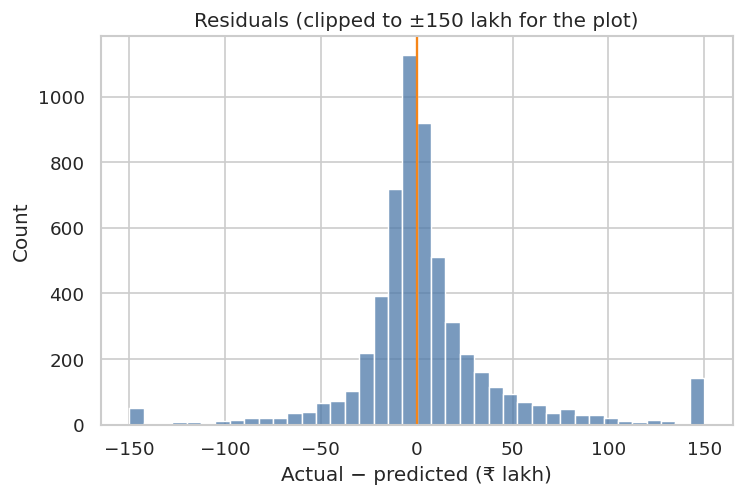

residual median: -0.37
residual mean:   7.64


In [15]:
resid = y_test_lakh - boost_pred
fig, ax = plt.subplots(figsize=(6.8, 4.2))
sns.histplot(resid.clip(-150, 150), bins=40, ax=ax, color=BLUE)
ax.axvline(0, color=ORANGE, lw=1.4)
ax.set_xlabel("Actual − predicted (₹ lakh)")
ax.set_title("Residuals (clipped to ±150 lakh for the plot)")
fig.savefig(FIG_DIR / "residuals.png")
plt.show()
print("residual median:", round(float(np.median(resid)), 2))
print("residual mean:  ", round(float(np.mean(resid)), 2))


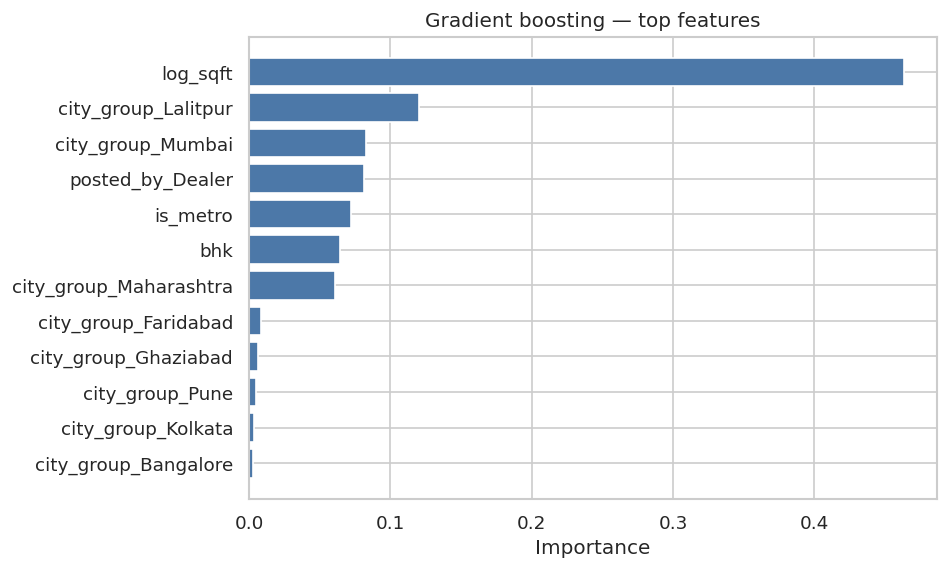

log_sqft                  0.4637
city_group_Lalitpur       0.1204
city_group_Mumbai         0.0828
posted_by_Dealer          0.0817
is_metro                  0.0721
bhk                       0.0643
city_group_Maharashtra    0.0608
city_group_Faridabad      0.0083
city_group_Ghaziabad      0.0061
city_group_Pune           0.0048
city_group_Kolkata        0.0038
city_group_Bangalore      0.0025
dtype: float64


In [16]:
ohe = boost.named_steps["prep"].named_transformers_["cat"]
names = np.concatenate([NUMERIC, ohe.get_feature_names_out(CATEGORICAL)])
imp = (
    pd.Series(boost.named_steps["model"].feature_importances_, index=names)
    .sort_values(ascending=True)
    .tail(12)
)
fig, ax = plt.subplots(figsize=(7.4, 5.0))
ax.barh(imp.index, imp.values, color=BLUE)
ax.set_xlabel("Importance")
ax.set_title("Gradient boosting — top features")
fig.savefig(FIG_DIR / "feature_importance.png")
plt.show()
print(imp.sort_values(ascending=False).round(4))


Area does most of the work, then the Mumbai-ish city buckets (`Lalitpur`,
`Mumbai`, `Maharashtra`) and whether a dealer posted it. That matches
the plots.

`Lalitpur` ranking high is the mislabeled MMR listings, not a sudden
housing boom in Bundelkhand.


In [17]:
out_model = MODEL_DIR / "gradient_boosting.joblib"
joblib.dump(
    {
        "model": boost,
        "keep_cities": sorted(KEEP_CITIES),
        "metros": sorted(METROS),
        "numeric": NUMERIC,
        "categorical": CATEGORICAL,
    },
    out_model,
)
print("saved", out_model.relative_to(ROOT))

reloaded = joblib.load(out_model)
pipe = reloaded["model"] if isinstance(reloaded, dict) else reloaded
sample_pred = np.expm1(pipe.predict(X_test.iloc[:5]))
print("sample predictions ₹ lakh:", np.round(sample_pred, 1))
print("actual:                    ", np.round(y_test_lakh.iloc[:5].to_numpy(), 1))


saved models/gradient_boosting.joblib
sample predictions ₹ lakh: [ 45.1  87.8  65.9 231.5  47.1]
actual:                     [ 30.   59.5  45.  120.   66. ]


## 7. What I would not claim

- These are asking prices, not sold prices.
- No floor number, age, parking, or “near metro”. City + sq ft is rough.
- Lalitpur / Maharashtra are messy labels. Coordinates are swapped and
  sometimes not even in India.
- I cannot score the Kaggle test file. It has no target.
- A 29% MAPE is “in the ballpark”, not a valuation engine.

If I kept going I would try a cleaner Mumbai-region remap from the
locality token (Thane, Mulund, Kharghar, …) and a per-city model for
the five biggest markets.
